# Multi-Agent Interaction Analysis — 3/31 Improvements

In [1]:
import json
import glob
import re
import matplotlib.pyplot as plt
from matplotlib_venn import venn2, venn3

%matplotlib inline

## Constants

In [2]:
STOP_WORDS = {
    "the", "a", "an", "and", "or", "but", "in", "on", "at", "to", "for",
    "of", "with", "is", "it", "that", "this", "we", "i", "you", "they",
    "be", "are", "was", "were", "have", "has", "had", "not", "about",
    "their", "our", "can", "just", "so", "if", "when", "how", "what",
    "more", "really", "think", "feel", "truly", "also", "still", "even",
    "would", "could", "should", "might", "need", "use", "used", "using",
    "do", "did", "does", "been", "being", "all", "some", "any", "no",
    "up", "out", "than", "then", "my", "me", "him", "her", "its", "am",
    "very", "well", "here", "there", "from", "into", "by", "as", "like",
    "will", "get", "much", "too", "point", "way", "good", "right", "see",
    "things", "something", "sure", "bit", "make", "going", "want", "know",
    "actually", "perhaps", "maybe", "quite", "however", "though", "while",
    "across", "them", "us", "those", "these", "each", "both", "only",
    "already", "yes", "no", "own", "agree", "think", "believe", "feel"
}

KEY_THEMES = [
    "critical thinking", "over-rely", "dependency", "misuse", "fairness",
    "creativity", "personalize", "personalized", "guidelines", "boundaries",
    "responsibility", "responsible", "access", "equity", "engagement",
    "brainstorm", "research", "feedback", "learning", "harm",
    "benefits", "risks", "moderation", "integrity", "shortcuts",
    "skills", "independent", "reliance", "support", "adoption"
]

## Helper Functions

In [3]:
def extract_themes(text: str) -> set:
    text = text.lower()
    found = set()
    for theme in KEY_THEMES:
        if theme in text:
            found.add(theme)
    return found


def load_trial(path: str) -> dict:
    with open(path, encoding="utf-8") as f:
        return json.load(f)


def get_trial_themes(trial: dict) -> set:
    themes = set()
    for agent in trial["agents"]:
        for trace in agent["traces"]:
            for field in ["observation_summary", "thought", "influence_analysis",
                          "updated_belief", "updated_goal", "message"]:
                if field in trace:
                    themes |= extract_themes(trace[field])
        themes |= extract_themes(agent.get("final_belief", ""))
        for mem in agent.get("memories", []):
            themes |= extract_themes(mem)
    return themes


def get_trial_stances(trial: dict) -> dict:
    return {
        agent["name"]: agent["stance_history"]
        for agent in trial["agents"]
    }

## Analysis Functions

In [4]:
def print_venn_sets(sets: list[set], labels: list[str]):
    all_themes = set().union(*sets)
    shared_all = sets[0].copy()
    for s in sets[1:]:
        shared_all &= s

    unique = [s - set().union(*[sets[j] for j in range(len(sets)) if j != i])
              for i, s in enumerate(sets)]

    print("\n=== Theme Analysis Across Trials ===")
    print(f"\nShared across ALL {len(sets)} trials:")
    for t in sorted(shared_all):
        print(f"  \u2022 {t}")

    for i, label in enumerate(labels):
        print(f"\nUnique to {label}:")
        for t in sorted(unique[i]):
            print(f"  \u2022 {t}")

    print(f"\nAll themes observed (any trial): {sorted(all_themes)}")


def plot_venn(sets: list[set], labels: list[str], title: str):
    fig, axes = plt.subplots(1, len(sets) - 1, figsize=(6 * (len(sets) - 1), 5))
    if len(sets) - 1 == 1:
        axes = [axes]

    for i in range(len(sets) - 1):
        ax = axes[i]
        a, b = sets[i], sets[i + 1]
        la, lb = labels[i], labels[i + 1]
        venn2([a, b], set_labels=(la, lb), ax=ax)
        ax.set_title(f"{la} vs {lb}")

    fig.suptitle(title, fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig("venn_diagram.png", dpi=150)
    plt.show()
    plt.close()


def plot_stance_evolution(all_stances: list[dict], trial_labels: list[str]):
    agents = list(all_stances[0].keys())
    stance_to_num = {"supportive": 1, "balanced": 0, "skeptical": -1}
    colors = {"Alice": "#4C9BE8", "Bob": "#E85C5C", "Carol": "#6DBF6D", "David": "#F5A623"}

    fig, axes = plt.subplots(1, len(agents), figsize=(4 * len(agents), 4), sharey=True)
    fig.suptitle("Stance Evolution per Agent Across Trials", fontsize=13, fontweight="bold")

    for ax, agent in zip(axes, agents):
        for i, (stances, label) in enumerate(zip(all_stances, trial_labels)):
            history = stances.get(agent, [])
            nums = [stance_to_num.get(s, 0) for s in history]
            rounds = list(range(1, len(nums) + 1))
            ax.plot(rounds, nums, marker="o", label=label, alpha=0.7,
                    color=plt.cm.tab10(i / len(trial_labels)))

        ax.set_title(agent, color=colors.get(agent, "black"), fontweight="bold")
        ax.set_yticks([-1, 0, 1])
        ax.set_yticklabels(["skeptical", "balanced", "supportive"])
        ax.set_xlabel("Round")
        ax.set_xticks(range(1, 4))
        ax.grid(True, alpha=0.3)

    axes[-1].legend(title="Trial", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig("stance_evolution.png", dpi=150)
    plt.show()
    plt.close()

## Load Trial Data

In [5]:
paths = sorted(glob.glob("trial_*.json"))
if not paths:
    print("No trial_*.json files found. Run main.py first.")
else:
    trials = [load_trial(p) for p in paths]
    labels = [f"Trial {t['trial_id']}" for t in trials]
    theme_sets = [get_trial_themes(t) for t in trials]
    all_stances = [get_trial_stances(t) for t in trials]
    print(f"Loaded {len(trials)} trial(s): {labels}")

Loaded 5 trial(s): ['Trial 1', 'Trial 2', 'Trial 3', 'Trial 4', 'Trial 5']


## Theme Analysis

In [6]:
print_venn_sets(theme_sets, labels)


=== Theme Analysis Across Trials ===

Shared across ALL 5 trials:
  • adoption
  • critical thinking
  • engagement
  • guidelines
  • learning
  • reliance
  • responsible
  • skills
  • support

Unique to Trial 1:

Unique to Trial 2:
  • research

Unique to Trial 3:

Unique to Trial 4:

Unique to Trial 5:

All themes observed (any trial): ['adoption', 'benefits', 'boundaries', 'creativity', 'critical thinking', 'dependency', 'engagement', 'guidelines', 'independent', 'learning', 'misuse', 'moderation', 'reliance', 'research', 'responsibility', 'responsible', 'risks', 'skills', 'support']


## Venn Diagram: Theme Overlap Across Trials

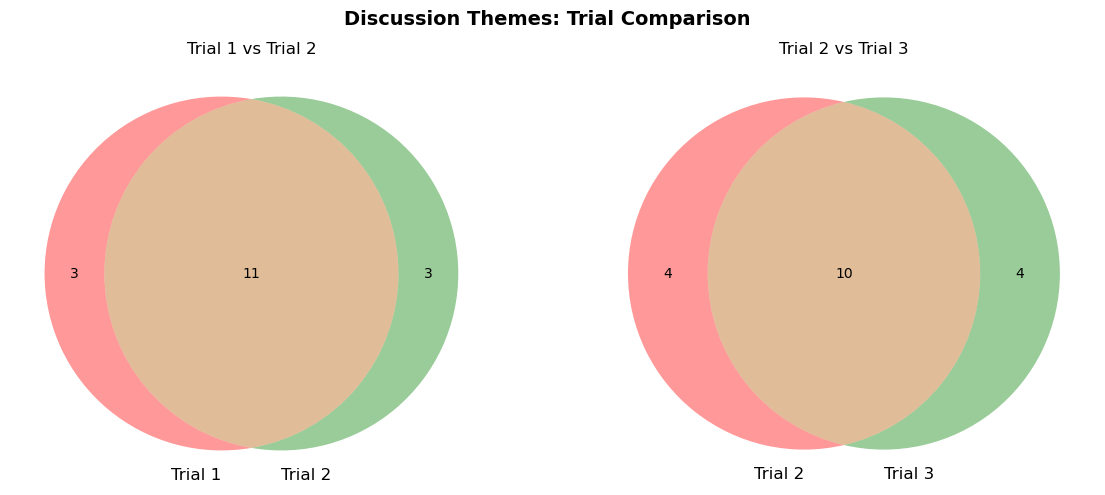

In [7]:
plot_venn(theme_sets[:3], labels[:3], "Discussion Themes: Trial Comparison")

## Stance Evolution per Agent

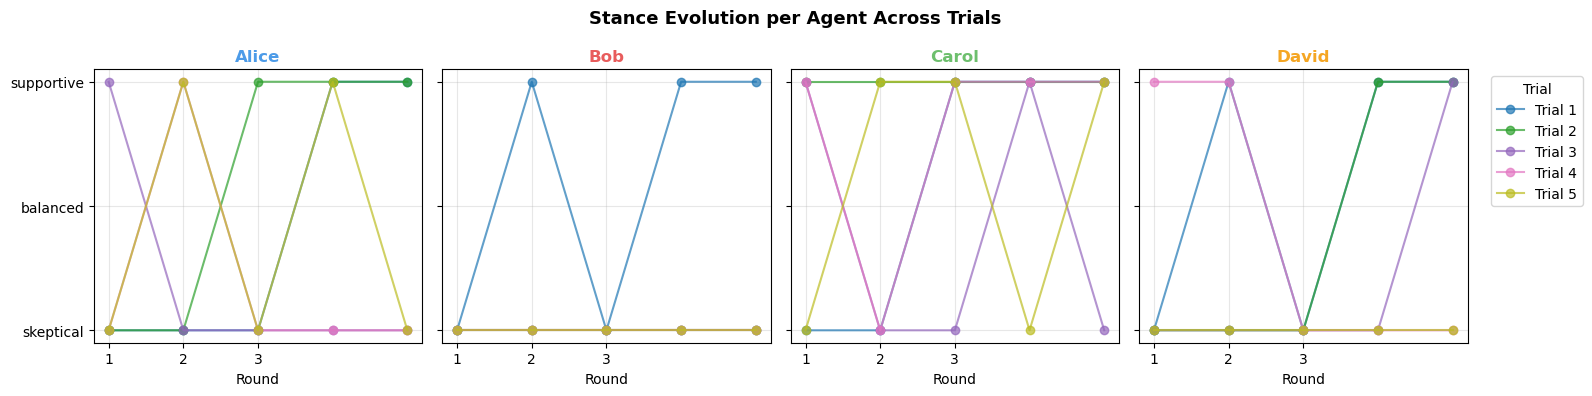

<function __main__.plot_stance_evolution(all_stances: list[dict], trial_labels: list[str])>

In [8]:
plot_stance_evolution(all_stances, labels)
plot_stance_evolution